
# LSN Exercises 07
## Molecular dynamics, autocorrelation and g(r)

Gabriele Borroni (14768A)

---
## Tail corrections

In the calculation of the potential energy $U$ and pressure $P$ implemented in the **NSL\_SIMULATOR**, a cutoff radius $r_c$ was introduced.  
As the name suggests, this cutoff truncates any contribution to $U$ and $P$ from pairs of particles separated by a distance larger than $r_c$.  

This truncation is an approximation: it makes the computation manageable by limiting the number of interactions, but it also neglects part of the long-range contribution of the potential.  
To compensate for the missing portion, a **tail correction** is added, restoring the contribution from the long-range part of the potential (and therefore also to the pressure).

For the Lennard–Jones potential, integrating from $r = r_c$ to $\infty$, the tail corrections to the potential energy and pressure are given by:

$$
\frac{\langle U \rangle^{\text{tail}}}{N} 
= 8 \pi \rho \epsilon \left[ \frac{1}{9 r_c^9} - \frac{1}{3 r_c^3} \right],
$$

$$
\frac{\langle W \rangle^{\text{tail}}}{3N \epsilon} 
= 32 \pi \rho \left[ \frac{1}{9 r_c^9} - \frac{1}{6 r_c^3} \right],
$$

where $r_c$ and $\rho$ are expressed in reduced units, and $\epsilon = 1$ is the unit of energy.

the first part of the exercise consists in adding this simple correction to the code, in system.cpp. The second part is focused on autocorrelation functions.

## Memory and Autocorrelation

A key concept to understand the use of autocorrelation functions is **memory**.
In complex systems with non-trivial dynamics, memory refers to the ability of past states or events to influence the future evolution of the process.

We start by defining the **covariance** between two random processes $(x_i, x_j)$, and the **variance** as:

$$
\operatorname{cov}[x_i, x_j](t_1, t_2) := 
\langle x_i(t_1) x_j(t_2) \rangle - \langle x_i(t_1) \rangle \langle x_j(t_2) \rangle,
$$

$$
\operatorname{var}[x](t) = \sigma_x^2 \equiv \operatorname{cov}[x, x](t, t).
$$

For a stationary random process $x$, the **autocorrelation function** is defined as the normalized covariance of the process with a time-delayed copy of itself.  
For any lag time $t' > 0$:

$$
\chi_x(t') := 
\frac{\operatorname{cov}[x, x](t, t+t')}{\operatorname{var}[x](t)}
= \frac{\langle x(t')x(t+t')\rangle - \langle x \rangle^2 }{\sigma_x^2}
$$

The autocorrelation function is a useful tool for studying the presence of memory or statistical dependence in a process.  
In practice, the goal is to determine how large the sampling blocks must be in order for them to behave as **statistically independent**.

In Markov Chain Monte Carlo (MC), **time is discrete**.  
Therefore, the autocorrelation function $\chi(t)$ can only be calculated for a finite set of MC time steps.  

  Suppose to have a set of samples of an observable $m(t)$ measured at evenly spaced intervals, up to a maximum time $t_{\max}$.  
  Then, the correct formula for the **autocorrelation function** is

$$
\chi(t) = 
\frac{
\frac{1}{t_{\max} - t} \sum_{t'=0}^{t_{\max}-t} m(t')\,m(t'+t)
- \frac{1}{t_{\max} - t} \sum_{t'=0}^{t_{\max}-t} m(t') \times 
\frac{1}{t_{\max} - t} \sum_{t'=0}^{t_{\max}-t} m(t'+t)
}{
\frac{1}{t_{\max}} \sum_{t'=0}^{t_{\max}} m^2(t')
- \left( \frac{1}{t_{\max}} \sum_{t'=0}^{t_{\max}} m(t') \right)^2
}.
$$


The **correlation time $t_c** is the typical time-scale on which the autocorrelation drops off. It quantifies how long the system retains significant correlation with its past, defining a **characteristic memory time** of the process. The autocorrelation is expected to fall off exponentially at long times, so that:
$$
\chi(t) \approx e^{-t/t_c}
$$

Thus, by choosing block sizes much larger than $\tau_c$, one can reasonably assume statistical independence between blocks, reducing memory effects in the sampled data.

To study the effects of correlations in the sampled data from the NSL_SIMULATOR code for both simulation types MC (N,V,T) and MD (N,V,E), two runs made up by 500k steps (after equilibration) and no blocks have been made, by sampling the same amount of data for $\frac{U}{N}$. 

The simulation parameters correspond to a liquid phase:
$$
\rho=0.8 \quad T=1.1 \quad N_{part}=108
$$
From the data gathered, the autocorrelation functions and the correlation time have been extimated in the block below.

In the autocorrelation plots it's possible to see an approximate fit for the theoretical autocorrelation time, which was obtained by integrating both sides from $0$ to $\infty$ (measurement start and end times):

$$
\int_0^\infty \chi(t)\,dt = \tau.
$$

The integral of $\chi(t)$ can be estimated numerically as

$$
\sum_i \chi_i \,\Delta T,
$$

where $\Delta T$ is the discrete time step (in this case $\Delta T = 1$).

In [6]:
import matplotlib.pyplot as plt
import numpy as np


U_MD=np.loadtxt("7.2/potential_energy_MD.dat")

U_MC=np.loadtxt("7.2/potential_energy_MC.dat")



def autocorrelation(data, t, tmax):
# if i pass a scalar, it returns a scalar, same for a vector
    chi=[]
    scalar_input=False
    if(np.isscalar(t)):
        t=[t]
        scalar_input=True
    #denominator is unchanged, calculate it once
    denominator=np.sum(data[:tmax]**2)/tmax-(np.sum(data[:tmax])/tmax)**2

    #loop over all the past times
    for tp in t:
        numerator=np.sum(data[:tmax-tp]*data[tp:tmax])/(tmax-tp)-(np.sum(data[:tmax-tp])/(tmax-tp)*np.sum(data[tp:tmax])/(tmax-tp))
        chi.append(numerator/denominator)

    if(scalar_input==True):
        return chi[0]
    else:
        return chi



#autocorrelation for 5k samples
t=U_MD[:1000,0].astype(int) #pass them as integer to be used as indexes

chi_MD=autocorrelation(U_MD[:,1],t, U_MD.shape[0])

chi_MC=autocorrelation(U_MC[:,1],t, U_MD.shape[0])



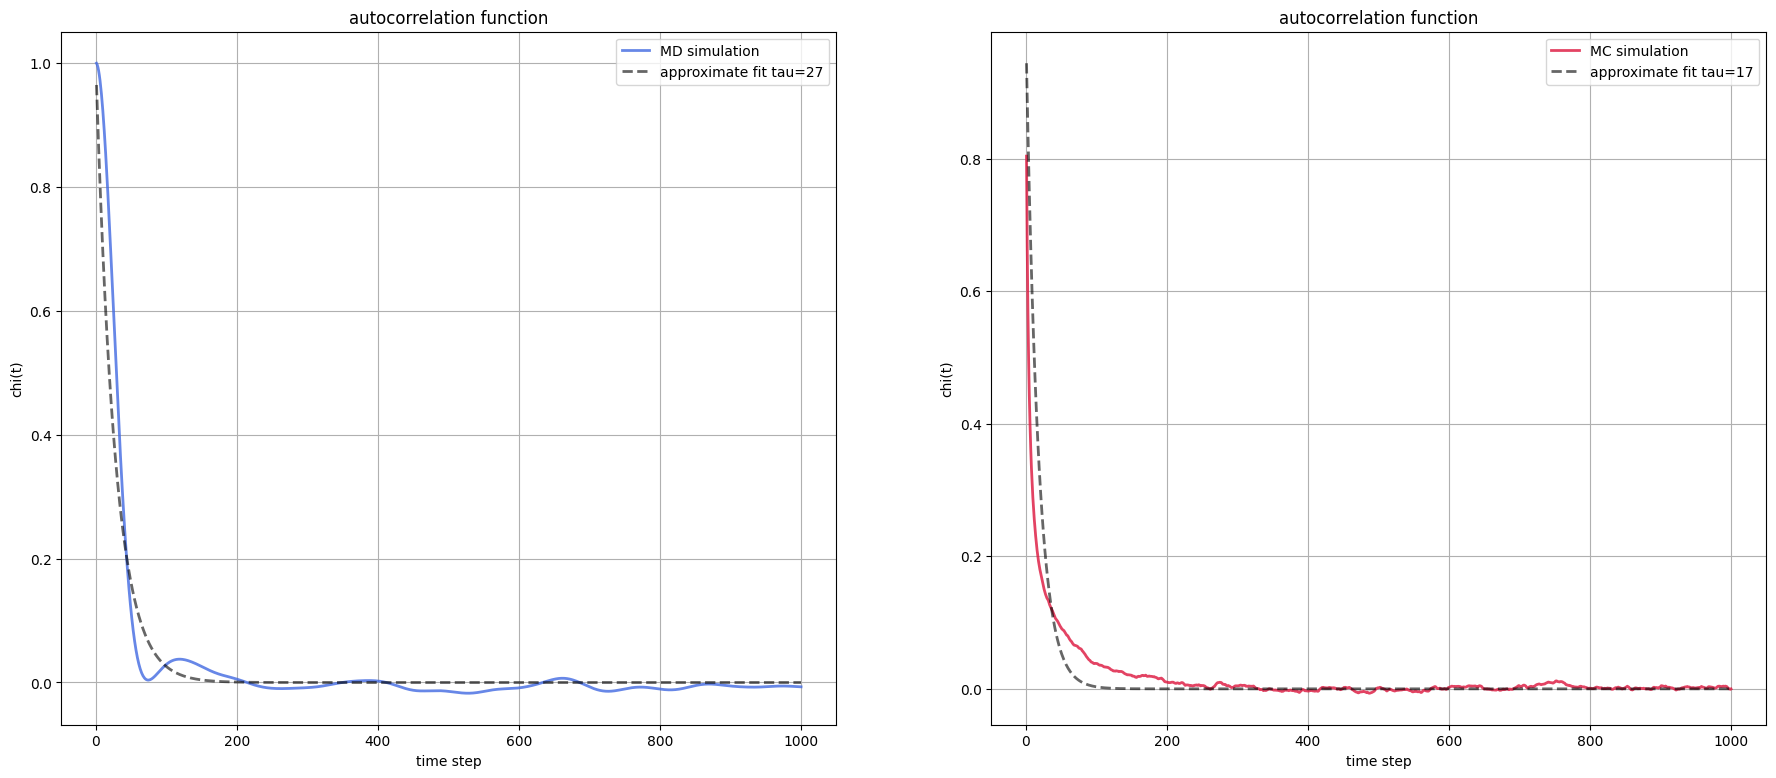

In [7]:
#plot
fig, ax=plt.subplots(1,2, figsize=(22,9))
tau_MD=np.sum(chi_MD)
tau_MC=np.sum(chi_MC)

ax[0].plot(t,chi_MD, label="MD simulation", color="royalblue", linewidth=2, alpha=0.8)
ax[0].plot(t,np.exp(-t/tau_MD), label=f"approximate fit tau={tau_MD.astype(int)}", color="black", linewidth=2, linestyle= "--" ,alpha=0.6)
ax[0].set_title("autocorrelation function")
ax[0].set_xlabel("time step")
ax[0].set_ylabel("chi(t)")
ax[0].grid(True)
ax[0].legend()

ax[1].plot(t,chi_MC, label="MC simulation", color="crimson", linewidth=2, alpha=0.8 )
ax[1].plot(t,np.exp(-t/tau_MC), label=f"approximate fit tau={tau_MC.astype(int)}", color="black", linewidth=2, linestyle= "--" ,alpha=0.6)
ax[1].set_title("autocorrelation function")
ax[1].set_xlabel("time step")
ax[1].set_ylabel("chi(t)")
ax[1].grid(True)
ax[1].legend()
plt.show()



This results highlight the fact that roughly every 27 steps for MD or 17 for MC it's possible to obtain statistically uncorrelated data.

In order to reduce correlations between blocks, their length should be at least greater than the autocorrelation time found.

Below, the same data has been processed used data blocking for different block lengths in the range $L\in[10, 5000]$ in order to find the optimal block length, which leads to the least correlation between data.

It is expected that:

- for $L \leq t_c$ the error will be underestimated due to the correlation between data

- for $L > t_c$ the error will start to become more stable, until they reach a plateu point, over which the data could safely be considered uncorrelated. That point represents the optimal block length, which will be used in the next part.

As it can be seen from the plot below, the optimal length value is around $L\approx10^3$

In [5]:
#N blocchi di lunghezza L=M/Nsteps=U_MD[::5000,0]
def data_blocking(data, Lmax):
    #divido i dati in blocchi e medio sui blocchi
    M=len(data)
    errors=[]
   # Lvalues=[L for L in range(10,Lmax+1) if M%L==0] #scorro solo sui divisori di M
    Lvalues=np.arange(6000)
    Lvalues[0]+=1
    for L in Lvalues:
        N=int(M/L)
        sum_average = 0.0
        sum_ave2 = 0.0

        for i in range(N):
            acc=0
            for j in range(L):
                acc+=data[i*L+j]

            block_ave = acc / L
            sum_average += block_ave
            sum_ave2 += block_ave ** 2

        average=sum_average/N
        ave2=sum_ave2/N
        errors.append(np.sqrt((ave2-average**2)/N))
        
    return errors,Lvalues

Lmax=5000
errors_MD , L =data_blocking(U_MD[:,1],Lmax)
errors_MC , L=data_blocking(U_MC[:,1],Lmax)




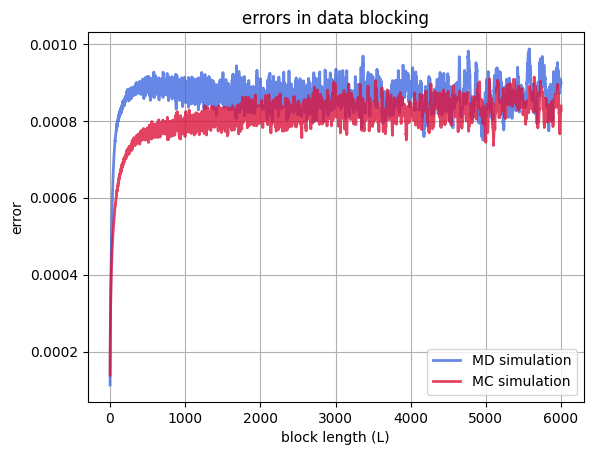

In [10]:
plt.plot(L,errors_MD, label="MD simulation", color="royalblue", linewidth=2, alpha=0.8)
plt.plot(L,errors_MC, label="MC simulation", color="crimson", linewidth=2, alpha=0.8 )

plt.xlabel("block length (L)")
plt.ylabel("error")
plt.title("errors in data blocking")
plt.legend()
plt.grid(True)
plt.show()

## Exercise 7.3

In `system.cpp` the **radial distribution function** $g(r)$ calculation has been implemented.  
This function represents the normalized probability of finding a particle at distance $r$ from a reference particle (relative to the expected value for an ideal gas at the same density).  

The function is defined as:

$$
g(r) = \frac{1}{\rho N \Delta V(r)} 
\left\langle \sum_{i \neq j = 1}^N 
\delta\!\big(|\vec{r}| - |\vec{r}_i - \vec{r}_j|\big) \right\rangle,
$$

where

$$
\Delta V(r) = \frac{4\pi}{3} \Big[ (r+dr)^3 - r^3 \Big].
$$

In practice, every time two particles are found at a distance $r+dr$, the corresponding bin of the histogram must be increased by 2.  
Finally, the histogram is normalized by the factor $\rho N \Delta V(r)$.

## Exercise 7.4: MC vs MD
Using the improved NSL code, both an MC-NVT simulation and an MD-NVE simulation are performed for Argon with the Lennard–Jones model under the following conditions:

- Liquid phase: $\rho = 0.8$, $T = 1.1$, $r_c = 2.5$ (cutoff radius)

 Pressure, potential energy per particle, and radial distribution function $g(r)$.  
In the case of MC simulations, to implement the pressure calculation a kinetik-energy term of $3/2T$ has been included (energy equipartition theorem), since in Monte Carlo simulations there is no molecular dynamics and therefore no kinetic energy to be computed during the run.  

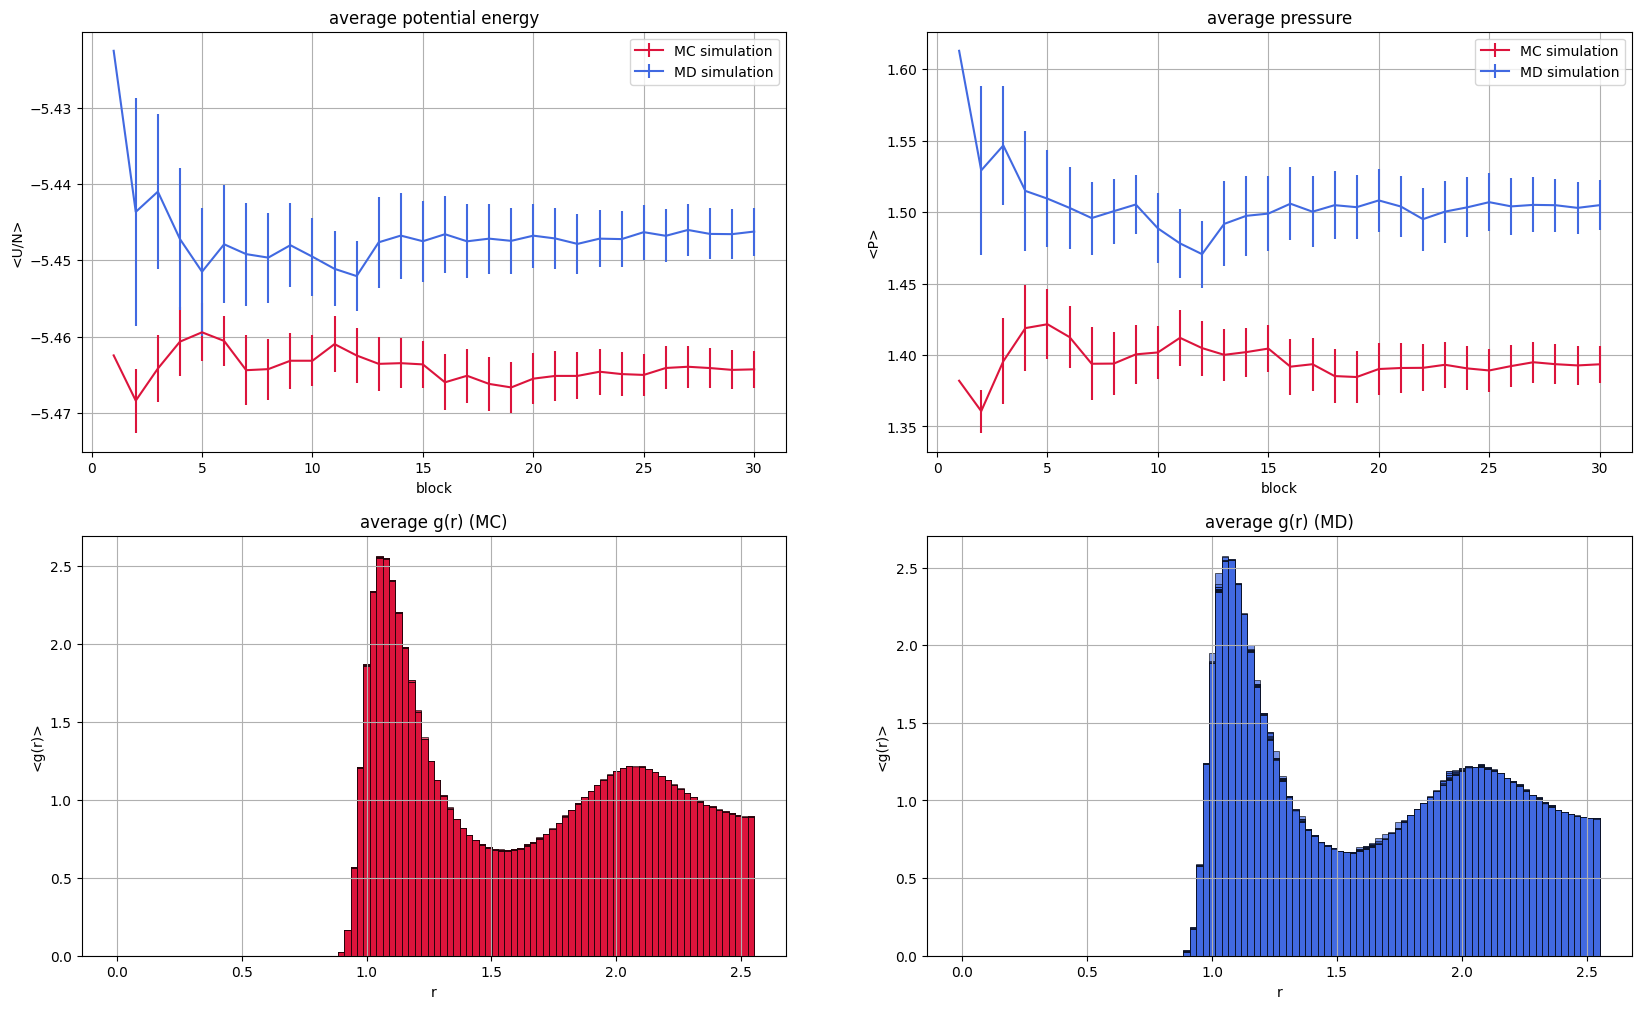

In [27]:
import matplotlib.pyplot as plt
import numpy as np


U_MC_data=np.loadtxt("7.4/potential_energy_MC.dat")
blocks=U_MC_data[:,0]
U_MC=U_MC_data[:,2]
errU_MC=U_MC_data[:,3]
U_MD_data=np.loadtxt("7.4/potential_energy_MD.dat")
U_MD=U_MD_data[:,2]
errU_MD=U_MD_data[:,3]

P_MC_data=np.loadtxt("7.4/pressure_MC.dat")
P_MC=P_MC_data[:,2]
errP_MC=P_MC_data[:,3]

P_MD_data=np.loadtxt("7.4/pressure_MD.dat")
P_MD=P_MD_data[:,2]
errP_MD=P_MD_data[:,3]

gofr_MC_data=np.loadtxt("7.4/gofr_MC.dat")
d=gofr_MC_data[:,0]
gofr_MC=gofr_MC_data[:,2]
errgofr_MC=gofr_MC_data[:,3]

gofr_MD_data=np.loadtxt("7.4/gofr_MD.dat")
gofr_MD=gofr_MD_data[:,2]
errgofr_MD=gofr_MD_data[:,3]

fig, ax= plt.subplots(2,2, figsize=(20,12))
ax=ax.flatten()
ax[0].errorbar(blocks,U_MC, yerr=errU_MC, color='crimson', label="MC simulation")
ax[0].errorbar(blocks,U_MD, yerr=errU_MD, color='royalblue' ,label="MD simulation")
ax[0].set_xlabel("block")
ax[0].set_ylabel("<U/N>")
ax[0].set_title("average potential energy")
ax[0].grid(True)
ax[0].legend()

ax[1].errorbar(blocks,P_MC, yerr=errP_MC, color='crimson', label="MC simulation")
ax[1].errorbar(blocks,P_MD, yerr=errP_MD, color='royalblue', label="MD simulation")
ax[1].set_xlabel("block")
ax[1].set_ylabel("<P>")
ax[1].set_title("average pressure")
ax[1].grid(True)
ax[1].legend()

ax[2].bar(d, gofr_MC, width=(d[1]-d[0]), align='center', alpha=0.7, color='crimson', edgecolor='black', linewidth=0.6)
ax[2].set_xlabel("r")
ax[2].set_ylabel("<g(r)>")
ax[2].set_title("average g(r) (MC)")
ax[2].grid(True)


ax[3].bar(d, gofr_MD, width=(d[1]-d[0]), align='center', alpha=0.7, color='royalblue', edgecolor='black', linewidth=0.6)
ax[3].set_xlabel("r")
ax[3].set_ylabel("<g(r)>")
ax[3].set_title("average g(r) (MD)")
ax[3].grid(True)


plt.show()



These results demonstrate that Molecular Dynamics (based on Newton’s equations of motion) and Monte Carlo (based on statistical sampling) yield consistent thermodynamic averages in the large-system limit. The small discrepancies observed in pressure and potential energy arise mainly from two factors:

- The thermodynamic limit is not fully reached in these simulations, since the system size is still far from Avogadro’s number.

- The temperature is treated differently in the two methods: in MD it fluctuates around an average value, while in MC it is fixed at $T = 1.1$.